In [1]:
import os

os.chdir("..")

Summarizing Data
================

:::{admonition} Learning Objectives
* Map a function over data frame columns
* Map a function over grouped data frame rows
* Describe the popular data visualization packages for Python
* Use the grammar of graphics to create a visualization
* Save a visualization to a file
:::

## Recap

You'll need the parks data from previous sections again for this section:

In [2]:
import numpy as np
import pandas as pd

parks = pd.read_csv("data/parks_final.csv")

### Data Structures & Types

Python provides several built-in data types such as `int`, `float`, `bool`,
`str`, and `list`. You can check the type of an object with the `type`
function.

Pandas provides a `Series` data structure, which is similar to a list, but has
more features. For the elements of a Series, Pandas uses data types which are
more specific than Python's data types. These usually have the same names as
Python's data types but also specify the number of bits for the data (for
example, `int64`). Pandas uses the `obj` data type for a Series which contains
strings or a mix of several different types of elements. You can check the data
type of a Series with the `.dtype` attribute.

Pandas also provides a `DataFrame` data strucure, which represents tabular
data. Each column in a DataFrame is a Series. You can check the data types of
the columns in a DataFrame with the `.dtypes` attribute.

### Exploring Series & DataFrames

Pandas Series and DataFrames have several descriptive attributes:

* `.index` is the names of the elements or rows
* `.shape` is the dimensions

They also have several summary methods:

* `.head` selects the first 5 elements or rows
* `.describe` computes common summary statistics
* `.value_counts` computes the frequency of each unique value
 
For a DataFrame, these three summary methods are computed per-column.
DataFrames also have a `.columns` attribute for the names of the columns and a
`.info` method which prints a summary of the structure.


### Indexing

Python's built-in **indexing operator** is the square brackets `[ ]`. Indexing
an object retrieves elements from the object, but the details differ depending
on the object's type.

For a list, the indexing operator selects elements by position. As the
index, you can use a single integer, a list of integers, or a **slice**. A
slice, written `a:b`, selects all elements from `a` up to but not including
`b`. Negative indices count backwards from the right edge of the list (so
`x[-1]` gets the *last* element of a list).

Pandas provides three different ways to index Series and DataFrames:

* `.iloc[ ]` selects elements by position
* `.loc[ ]` selects elements by name or by condition (a Boolean array)
* `[ ]` selects elements by position, name, or condition

DataFrames are two-dimensional, so generally you need to provide two different
arguments when you index them. A `:` argument, like the second argument in
`parks.iloc[1, :]`, selects all elements along that axis (so this code selects
the first row and all columns).


### Special Values

Python represents the absence of a value with `None`.

NumPy represents the result of an undefined numerical computation such as
`np.log(-1)` with `np.nan`. "nan" stands for **not a number**.

Pandas uses both `None` and `np.nan` to represent **missing values**, values
which were left out of a data set due to how the data was collected. Recent
versions of Pandas also use `pd.NA` for this purpose.

For a Series or DataFrame, you can use the `.isna` method to detect all three
kinds of missing values.



## Aggregating Data

The Pandas `.aggregate` method **aggregates** the elements of a Series,
reducing the Series to a smaller number of values (usually 1 value). For
example, to compute the mean of the `restroom_data` column in the parks data:

In [3]:
parks["restroom_data"].aggregate("mean")

2.129276315789474

The `.agg` method is an alias for `.aggregate`:

In [4]:
parks["restroom_data"].agg("mean")

2.129276315789474

You can pass `.aggregate` functions instead of names of functions. For
instance:

In [5]:
parks["restroom_data"].agg(np.mean)

2.129276315789474

You can also pass `.aggregate` a list of names or functions:

In [6]:
parks["restroom_data"].agg([np.mean, "median"])

mean      2.129276
median    1.900000
Name: restroom_data, dtype: float64

Pandas provides alias methods such as `.sum`, `.mean`, `.median`, and `.std`
for the most common aggregation functions. For example, to compute the mean:

In [7]:
parks["restroom_data"].mean()

2.129276315789474

The aggregation methods also work with DataFrames, where they are applied
separately to each column. Here's an example of computing medians for a few
columns in the parks data:

In [8]:
parks[["restroom_data", "basketball_data"]].median()

restroom_data      1.9
basketball_data    2.7
dtype: float64

### Aggregating within Groups

Aggregation is especially useful when combined with grouping. The `.groupby`
method groups the rows of a DataFrame using the columns you specify. The
grouping columns should generally be categories rather than decimal numbers.
For example, to group the parks data by city and then compute the mean number
of restrooms per 10,000 people in each city:

In [9]:
parks.groupby("city")["restroom_data"].mean()

city
Albuquerque       1.433333
Anaheim           2.833333
Anchorage         2.900000
Arlington         2.300000
Atlanta           0.466667
                    ...   
Tulsa             1.733333
Virginia Beach    2.200000
Washington        2.533333
Wichita           3.300000
Winston-Salem     2.233333
Name: restroom_data, Length: 100, dtype: float64

Similarly, to group the parks data by state and year and compute the median
number of basketball hoops per group:

In [10]:
parks.groupby(["state", "year"])["basketball_data"].median()

state      year
Alaska     2015    2.70
           2016    2.70
           2017    2.60
           2018    2.60
           2019    1.70
                   ... 
Wisconsin  2016    8.25
           2017    7.95
           2018    8.15
           2019    8.15
           2020    8.10
Name: basketball_data, Length: 289, dtype: float64

By default, the grouping columns are moved into the index of the result. You
can prevent this by setting `as_index = False` in `.groupby`:

In [11]:
parks.groupby(["state", "year"], as_index = False)["basketball_data"].median()

,state,year,basketball_data
0,Alaska,2015,2.70
1,Alaska,2016,2.70
2,Alaska,2017,2.60
3,Alaska,2018,2.60
4,Alaska,2019,1.70
...,...,...,...
284,Wisconsin,2016,8.25
285,Wisconsin,2017,7.95
286,Wisconsin,2018,8.15
287,Wisconsin,2019,8.15


:::{tip}
You can also "reset" the index on a DataFrame, so that the current indexes
become columns with the `.reset_index` method.
:::

Leaving the grouping columns in the index is often convenient because then you
can easily access results for the groups you're interested in:

In [12]:
state_medians = parks.groupby(["state", "year"])["basketball_data"].median()

# All states, year 2017
state_medians.loc[:, 2017]

state
Alaska                  2.60
Arizona                 2.10
California              2.60
Colorado                1.70
District of Columbia    4.00
Florida                 3.75
Georgia                 2.35
Hawaii                  5.70
Idaho                   2.20
Illinois                3.10
Indiana                 2.00
Kansas                  1.35
Kentucky                3.10
Louisiana               3.35
Maryland                1.60
Massachusetts           3.40
Michigan                3.20
Minnesota               7.30
Missouri                2.15
Nebraska                4.45
Nevada                  2.90
New Jersey              2.05
New Mexico              2.30
New York                4.95
North Carolina          2.00
Ohio                    3.45
Oklahoma                2.20
Oregon                  3.80
Pennsylvania            3.85
Tennessee               3.00
Texas                   2.20
Virginia                4.10
Washington              1.90
Wisconsin               7.95
Name: ba

A few aggregation functions only make sense when used together with groups. One
is the `.first` method, which returns the first element or row. The `.first`
method is especially useful if all the values in a group are the same and you
want to reduce the data to one row per group. For instance, in the parks data
set, the `pop2020` only has one value per city across all the years. So you can
get the 2020 population for each city with this code:

In [13]:
parks.groupby(["state", "city"])["pop2020"].first()

state       city          
Alaska      Anchorage          291247.0
Arizona     Chandler           275987.0
            Glendale           248325.0
            Mesa               504258.0
            Phoenix           1608139.0
                                ...    
Virginia    Richmond           226610.0
            Virginia Beach     459470.0
Washington  Seattle            737015.0
Wisconsin   Madison            269840.0
            Milwaukee          577222.0
Name: pop2020, Length: 106, dtype: float64

## Visualization in Python

```{image} ../img/visualization_landscape.png
:alt: A network of Python visualization packages.
```

_Image from [Jake VanderPlas][jake]. See [here][viz] for a version with links
to all of the packages!_

[jake]: http://vanderplas.com/
[viz]: https://rougier.github.io/python-visualization-landscape/landscape-colors.html

So many visualization packages are available for Python that there is even [a
website][pyviz] dedicated to helping people decide which to use. This reader
focuses on **static visualization**, where the visualization is a still image.
Some popular packages for creating static visualizations are:

[pyviz]: https://pyviz.org/

* **[matplotlib][]** is the foundation for most other visualization packages.
  matplotlib is low-level, meaning it's flexible but even simple plots may take
  [5 lines of code or more][ex]. It's good to know a little bit about
  matplotlib, but it probably shouldn't be your primary visualization package.
  Familiarity with MATLAB makes it easier to learn matplotlib.

* **[pandas][]** provides built-in plotting functions, which can be convenient
  but are more limited than what you'll find in dedicated visualization
  packages. They're also inconsistent about the expected format of the data.

* **[plotnine][]** is a copy of the popular R package [ggplot2][]. The package
  uses the **grammar of graphics**, a convenient way to describe visualizations
  in terms of layers. Familiarity with R's [ggplot2][] or Julia's
  [Gadfly.jl][gadfly] package makes it easier to learn plotnine (and
  vice-versa).

* **[seaborn][]** is designed specifically for making statistical plots. It's
  well-documented and stable.

[matplotlib]: https://matplotlib.org/
[ex]: https://dsaber.com/2016/10/02/a-dramatic-tour-through-pythons-data-visualization-landscape-including-ggplot-and-altair/
[pandas]: https://pandas.pydata.org/docs/user_guide/visualization.html
[ggplot2]: https://ggplot2.tidyverse.org/
[plotnine]: https://plotnine.readthedocs.io/en/stable/
[gadfly]: http://gadflyjl.org/stable/
[seaborn]: https://seaborn.pydata.org/

There are also many packages available for making **interactive
visualizations**.

This reader focuses on plotnine, so that the visualization skills you learn
here will also be relevant if you end up using R or Julia. plotnine has
detailed [documentation][plotnine]. It's also useful to look at the [ggplot2
documentation][ggplot2] and [cheatsheet][ggplot2-cheat].

[ggplot2-cheat]: https://github.com/rstudio/cheatsheets/blob/master/data-visualization-2.1.pdf


### Configuring Jupyter

Jupyter notebooks can display most static visualizations and some interactive
visualizations. If you're going to use visualization packages that depend on
matplotlib (such as plotnine), it's a good idea to set up your notebook by
running:

In [14]:
# Initialize matplotlib

%matplotlib inline

import matplotlib.pyplot as plt

# We'll see what this code does later on:
plt.rcParams["figure.figsize"] = [10, 8]

The last line sets the default size of plots. You can increase the numbers to
make plots larger, or decrease them to make plots smaller.


## Installing Packages

Matplotlib is included with Anaconda, but plotnine is not. So you need to
install the plotnine package in order to use it.

You can use Anaconda's conda utility to install packages. The conda utility
is a program, not part of Python. In JupyterLab, open a Terminal (`File` ->
`New` -> `Terminal`). Then enter:

```
conda install -c conda-forge plotnine
```

The command `conda install PACKAGE` installs the package called `PACKAGE`. The
flag `-c conda-forge` tells conda to use a version from the conda-forge package
repository. Packages on conda-forge are usually more up to date than the ones
in Anaconda's default package repository.

You can learn more about Anaconda and conda in the [official
documentation][conda].

[conda]: https://docs.anaconda.com/anaconda/user-guide/tasks/install-packages/


## The Grammar of Graphics

plotnine is based on the grammar of graphics. The idea of a grammar of graphics
is that visualizations can be built up in layers. In plotnine, the three layers
every plot must have are:

* Data
* Geometry
* Aesthetics

There are also several optional layers. Here are a few:

Layer       | Description
----------  | -----------
scales      | Title, label, and axis value settings
facets      | Side-by-side plots
guides      | Axis and legend position settings
annotations | Shapes that are not mapped to data
coordinates | Coordinate systems (Cartesian, logarithmic, polar)


In {numref}`modules`, you learned to import a module in a Python package with
the `import` keyword. Python also provides a `from` keyword to import specific
objects within a module. The syntax is `from X import Y`, so for example you
can write `from pandas import DataFrame`. When you import an object this way,
you can access the object without the module name as a prefix. For instance,
you can then write `DataFrame` instead of `pd.DataFrame`.

You can also use the `from` keyword to import all objects in a module with the
wildcard syntax `from X import *`. You generally shouldn't do this, because
objects in the module will overwrite objects in your code if they have the same
name. However, the plotnine package is designed to be imported this way:

In [15]:
from plotnine import *

To learn how to use the package, let's make a plot with the parks data.

What kind of plot should we make? It depends on what data we want the plot to
show. Let's make a line plot that shows the number of playgrounds per 10,000
residents over the years for major cities in California.


### Preparing the Data

Before making a plot, you'll generally have to prepare the data by getting a
subset of the rows and columns in which you're interested. You can get a subset
by using the indexing techniques that were covered in
{numref}`indexing-dataframes`. Here's one way to get the rows for only the
cities in California:

In [16]:
ca_parks = parks.loc[parks["state"] == "California", ]
ca_parks.head()

,year,rank,city,med_park_size_data,med_park_size_points,park_pct_city_data,park_pct_city_points,pct_near_park_data,pct_near_park_points,spend_per_resident_data,...,splashground_data,splashground_points,amenities_points,total_points,total_pct,park_benches,state,pop2020,pop2010,area2020
6,2020,7,Irvine,6.1,28.0,27%,50.0,82%,73.0,$215,...,0.7,25.0,67.3,318.0,79.6,NaN,California,307670.0,212375.0,65.6
7,2020,8,San Francisco,1.3,4.0,21%,50.0,100%,100.0,$399,...,1.0,36.0,61.7,316.0,78.9,NaN,California,873965.0,805235.0,46.9
17,2020,18,San Diego,6.8,32.0,19%,50.0,81%,71.0,$153,...,0.1,2.0,37.2,276.0,69.0,NaN,California,1386932.0,1307402.0,325.9
22,2020,23,Long Beach,3.2,14.0,10%,25.0,84%,76.0,$180,...,0.2,4.0,50.0,265.0,66.3,NaN,California,466742.0,462257.0,50.7
30,2020,30,Sacramento,5.4,25.0,9%,21.0,83%,75.0,$122,...,4.5,100.0,60.2,248.0,62.0,NaN,California,524943.0,466488.0,98.6


### Layer 1: Data

The data layer determines the data set used to make the plot. plotnine is
designed for working with **tidy** data frames. Tidy means:

1. Each observation has its own row.
2. Each feature has its own column.
3. Each value has its own cell.

To set up the data layer, call the `ggplot` function on a data frame:

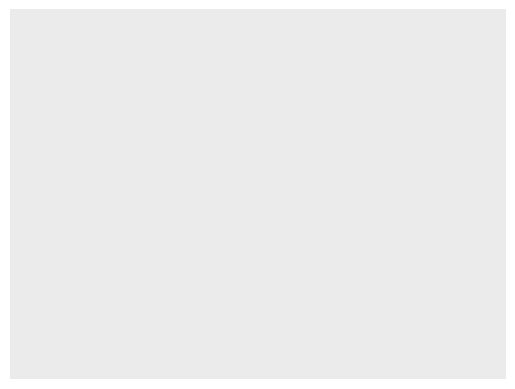

<ggplot: (315610515)>

In [17]:
ggplot(parks)

This returns a blank plot. We still need to add a few more layers.


### Layer 2: Geometry

The **geom**etry layer determines the shape or appearance of the visual
elements of the plot. In other words, the geometry layer determines what kind
of plot to make: one with points, lines, boxes, or something else.

There are many different geometries available in plotnine. The package provides
a function for each geometry, always prefixed with `geom_`.

To add a geometry layer to the plot, choose the `geom_` function you want and
add it to the plot with the `+` operator.

In [18]:
ggplot(parks) + geom_line()

KeyError: 'x'

This returns the error message `KeyError: 'x'`, which means the geometry needs
to know which column of data to use for the aesthetic `x`. We'll learn more
about aesthetics in the next section.


### Layer 3: Aesthetics

The **aes**thetic layer determines the relationship between the data and the
geometry. Use the aesthetic layer to map features in the data to **aesthetics**
(visual elements) of the geometry.

The `aes` function creates an aesthetic layer. The syntax is:

```
aes(AESTHETIC = FEATURE, ...)
```

The names of the aesthetics depend on the geometry, but some common ones are
`x`, `y`, `color`, `fill`, `shape`, and `size`. There is more information about
and examples of aesthetic names in the documentation.

For example, we want to put `year` on the x-axis and `playground_data` on the
y-axis. We also want to use a separate color for each `city`. So the aesthetic
layer should be:

```
aes(x = "year", y = "playground_data", color = "city")
```

Unlike most layers, the aesthetic layer is not added to the plot with the `+`
operator. Instead, pass the aesthetic layer as the second argument to the
`ggplot` function:

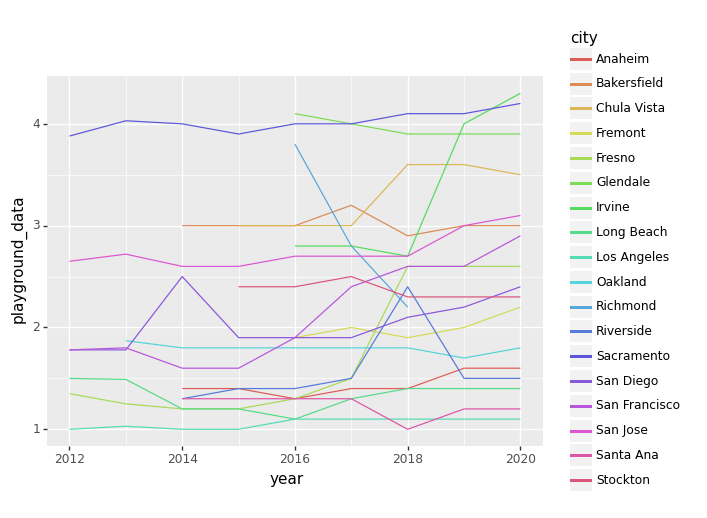

<ggplot: (319849839)>

In [19]:
(ggplot(ca_parks, aes(x = "year", y = "playground_data", color = "city")) +
  geom_line())

:::{tip}
Long lines of code tend to be hard to read, just like long lines of text. You
can break a line of code across multiple lines as long as you put the code
inside of parentheses, like the code above.
:::


### Refining Visualizations

Making a *good* plot is usually a refinement process, where you go through
several drafts before getting to one that communicates the information clearly.

For example, the plot above is visually cluttered. As a rule of thumb, line
plots shouldn't have more than 5 to 7 lines. The plot may also be difficult to
read for colorblind people, since the lines are only distinguished by color.

Let's change the plot so that it only shows California's 5 most populous
cities. You can use the `pop2020` column and grouping to determine which cities
those are:

In [20]:
top_cities = ca_parks.groupby("city")["pop2020"].first().sort_values()
top_cities = top_cities.tail(5).reset_index()["city"]
top_cities

0           Fresno
1    San Francisco
2         San Jose
3        San Diego
4      Los Angeles
Name: city, dtype: object

Now change the subset of the data:

In [21]:
ca5_parks = ca_parks.loc[ca_parks["city"].isin(top_cities)]
ca5_parks.head()

,year,rank,city,med_park_size_data,med_park_size_points,park_pct_city_data,park_pct_city_points,pct_near_park_data,pct_near_park_points,spend_per_resident_data,...,splashground_data,splashground_points,amenities_points,total_points,total_pct,park_benches,state,pop2020,pop2010,area2020
7,2020,8,San Francisco,1.3,4.0,21%,50.0,100%,100.0,$399,...,1.0,36.0,61.7,316.0,78.9,NaN,California,873965.0,805235.0,46.9
17,2020,18,San Diego,6.8,32.0,19%,50.0,81%,71.0,$153,...,0.1,2.0,37.2,276.0,69.0,NaN,California,1386932.0,1307402.0,325.9
37,2020,36,San Jose,3.0,13.0,15%,40.0,82%,74.0,$108,...,2.0,75.0,47.2,232.0,58.0,NaN,California,1013240.0,945942.0,178.3
52,2020,49,Los Angeles,4.8,22.0,13%,32.0,62%,42.0,$132,...,0.4,12.0,30.3,199.0,49.8,NaN,California,3898747.0,3792621.0,469.5
95,2020,92,Fresno,2.2,9.0,4%,8.0,67%,51.0,$42,...,0.9,33.0,42.0,127.0,31.8,NaN,California,542107.0,494665.0,115.2


Finally, recreate the plot. Showing only the top 5 cities reduces the number of
lines. To make the plot colorblind-friendly, add points with different shapes
to each line:

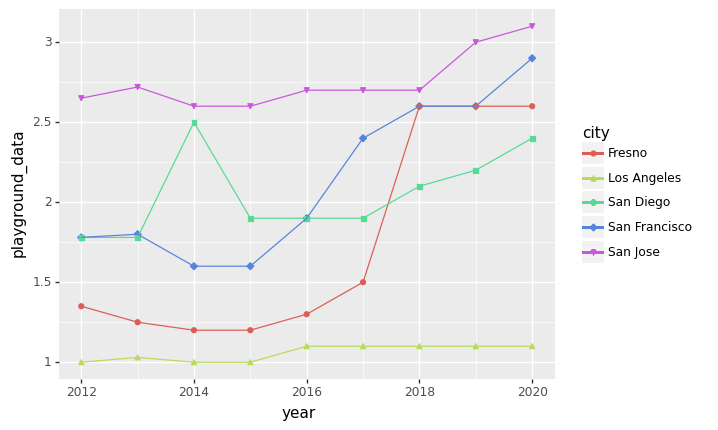

<ggplot: (319923426)>

In [22]:
(
  ggplot(ca5_parks, aes(x = "year", y = "playground_data", shape = "city",
    color = "city")) +
  geom_point() + geom_line()
)

If you want to set an aesthetic to a constant value, rather than one that's
data dependent, do so *outside* of the aesthetic layer. For instance, suppose
you want to make the points bigger:

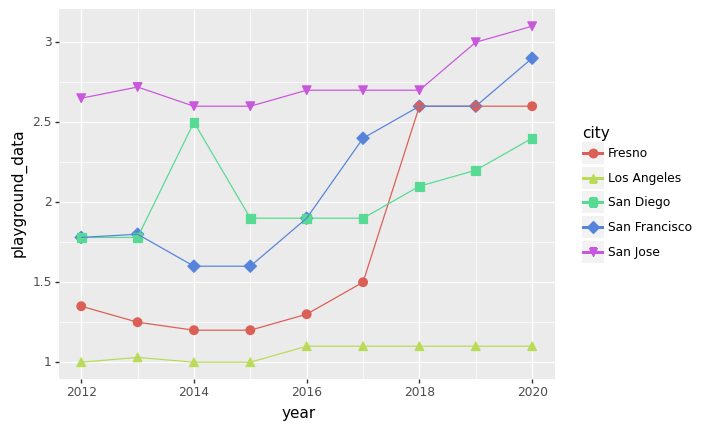

<ggplot: (320004066)>

In [23]:
(
  ggplot(ca5_parks, aes(x = "year", y = "playground_data", shape = "city",
    color = "city")) +
  geom_point(size = 3) + geom_line()
)

<!--
#### Per-geometry Aesthetics {-}

When you pass an aesthetic layer to the `ggplot` function, it applies to the
entire plot. You can also set an aesthetic layer individually for each
geometry, by passing the layer as the first argument in the `geom_` function:
```{r}
#ggplot(favs) + geom_point(aes(x = distance_mi, y = walk_min))
```

This is really only useful when you have multiple geometries. As an example,
let's color-code the points by major:
```{r}
#ggplot(favs, aes(x = distance_mi, y = walk_min, color = major)) +
#  geom_point()
```

Now let's also add labels to each point. To do this, we need to add another
geometry:
```{r}
#ggplot(favs, aes(x = distance_mi, y = walk_min, color = major, label = major)) +
#  geom_point() + geom_text(size = 2)
```

Where we put the aesthetics matters:
```{r}
#ggplot(favs, aes(x = distance_mi, y = walk_min, label = major)) +
#  geom_point() + geom_text(aes(color = major), size = 2)
```
-->

### Layer 4: Scales

The scales layer controls the title, axis labels, and axis scales of the plot.
Most of the functions in the scales layer are prefixed with `scale_`, but not
all of them.

The `labs` function is especially important, because it's used to set the title
and axis labels:

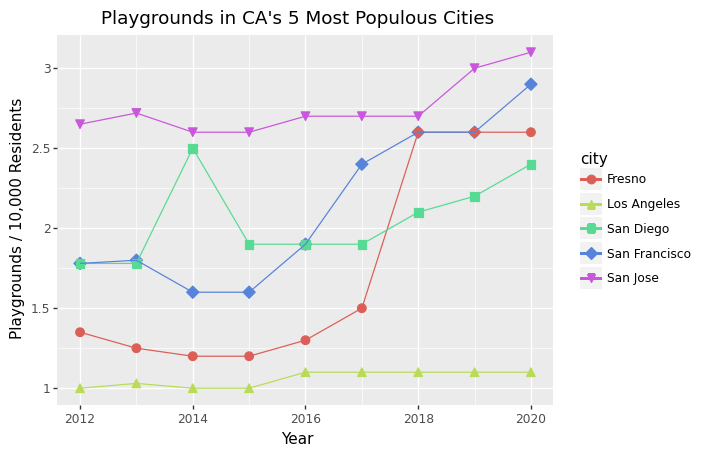

<ggplot: (320067056)>

In [24]:
(
  ggplot(ca5_parks, aes(x = "year", y = "playground_data", shape = "city",
    color = "city")) +
  geom_point(size = 3) + geom_line() +
  labs(x = "Year", y = "Playgrounds / 10,000 Residents",
    title = "Playgrounds in CA's 5 Most Populous Cities")
)

### Saving Plots

If you save a plot into a variable, you can use the `.save` method or the
`ggsave` function to save it to a file:

```
plot = (
  ggplot(ca5_parks, aes(x = "year", y = "playground_data", shape = "city",
    color = "city")) +
  geom_point(size = 3) + geom_line() +
  labs(x = "Year", y = "Playgrounds / 10,000 Residents",
    title = "Playgrounds in CA's 5 Most Populous Cities")
)

ggsave(plot, "line.pdf")
```

The file format is selected automatically based on the extension. Common
formats are PNG and PDF.


## Practice Exercises

### Exercise 1

Use plotnine and the parks data to make a bar plot that shows the number of
basketball hoops per 10,000 people in 2018 for 7 cities of your choosing.

:::{admonition} Hint
When you want to make a bar plot and you've already computed the values that go
on the y-axis, make sure to set `stat = "identity"` in the geometry function.
:::